In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso


In [2]:
df =pd.read_csv('homeDataset.csv')

In [3]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df = df.fillna(value = 'none')

In [7]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1203,1204,20,RL,75.0,9750,Pave,none,Reg,Lvl,AllPub,...,0,none,none,none,0,10,2009,WD,Normal,213000
372,373,120,RL,50.0,7175,Pave,none,Reg,Lvl,AllPub,...,0,none,MnPrv,none,0,2,2010,WD,Normal,125000
1132,1133,70,RM,90.0,9900,Pave,none,Reg,Lvl,AllPub,...,0,none,none,none,0,5,2007,WD,Normal,117500
1121,1122,20,RL,84.0,10084,Pave,none,Reg,Lvl,AllPub,...,0,none,none,none,0,7,2006,New,Partial,212900
467,468,70,RL,79.0,9480,Pave,none,Reg,Lvl,AllPub,...,0,none,none,none,0,6,2007,WD,Normal,146500


In [9]:
for i in df.columns :
    print(df[i].value_counts())
    print(df[i].dtype)
    print("........\n")

Id
1460    1
1       1
2       1
3       1
4       1
       ..
24      1
25      1
26      1
27      1
28      1
Name: count, Length: 1460, dtype: int64
int64
........

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64
int64
........

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
object
........

LotFrontage
none     259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
182.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 111, dtype: int64
object
........

LotArea
7200     25
9600     24
6000     17
10800    14
9000     14
         ..
1953      1
9735      1
8212      1
12925     1
25339     1
Name: count, Length: 1073, dtype: int64
int64
........

Street
Pave    1454
Grvl       6
Name: count, dtype: int64
object
........

In [10]:
df['MasVnrArea']= pd.to_numeric(df['MasVnrArea'],errors = 'coerce')

In [11]:
df['LotFrontage']  = pd.to_numeric(df['LotFrontage'],errors = 'coerce')

In [12]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [14]:
df['LotFrontage']=df['LotFrontage'].fillna(value = df['LotFrontage'].median())

In [15]:
df['LotFrontage'].value_counts()

LotFrontage
69.0     270
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
182.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [19]:
df['MasVnrArea'].fillna(value = df['MasVnrArea'].median(), inplace = True)

In [21]:
df['SalePrice'].skew()

np.float64(1.8828757597682129)

In [22]:
df['SalePrice'].kurt()

np.float64(6.536281860064529)

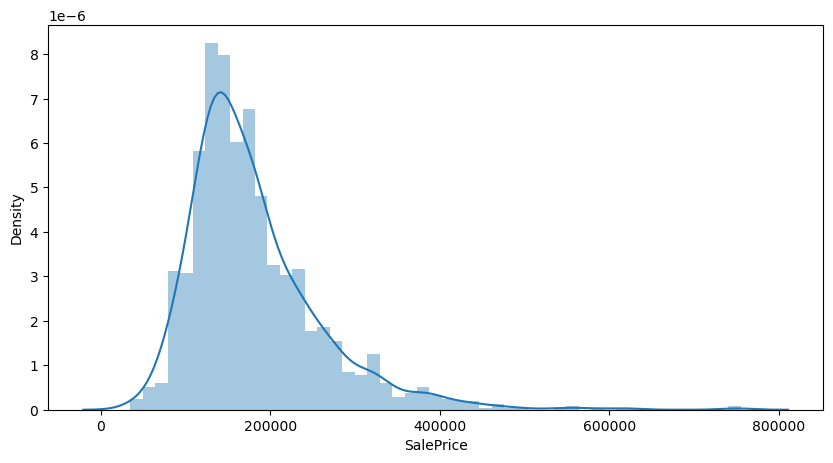

In [24]:
plt.figure(figsize = (10,5))
sns.distplot( df['SalePrice'])
plt.show()

In [25]:
df['SalePrice'] = np.log(df['SalePrice'])

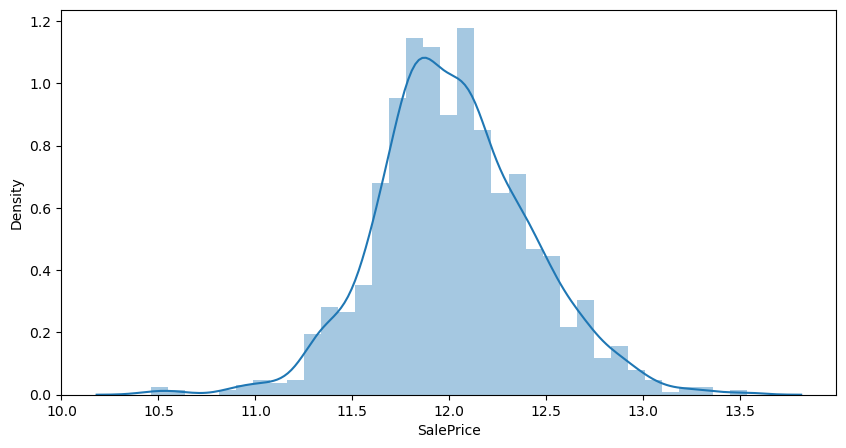

In [26]:
plt.figure(figsize = (10,5))
sns.distplot( df['SalePrice'])
plt.show()

In [33]:
df_num = df.select_dtypes(include = ['int64','float64'])

0.0


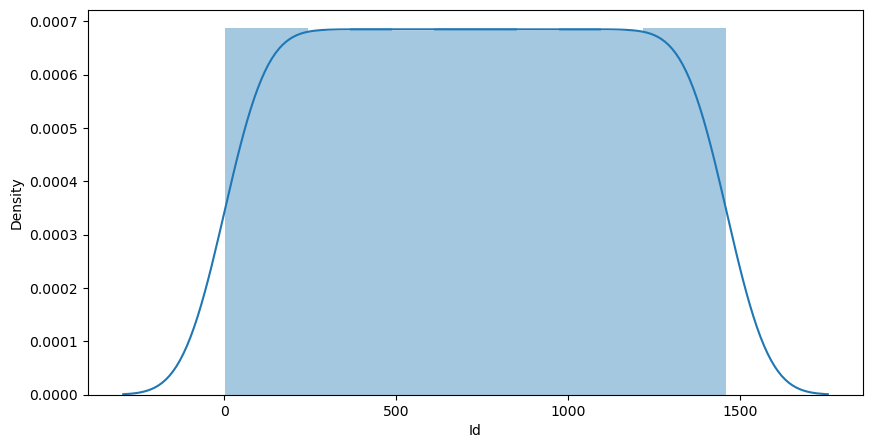

1.4076567471495591


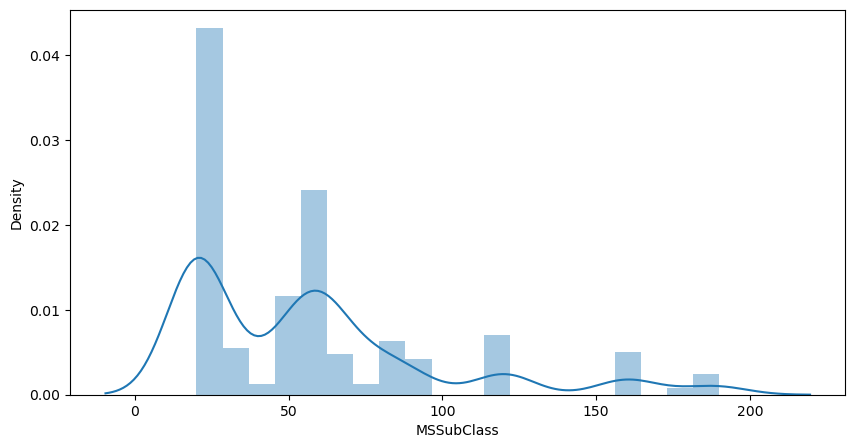

2.4091466665496006


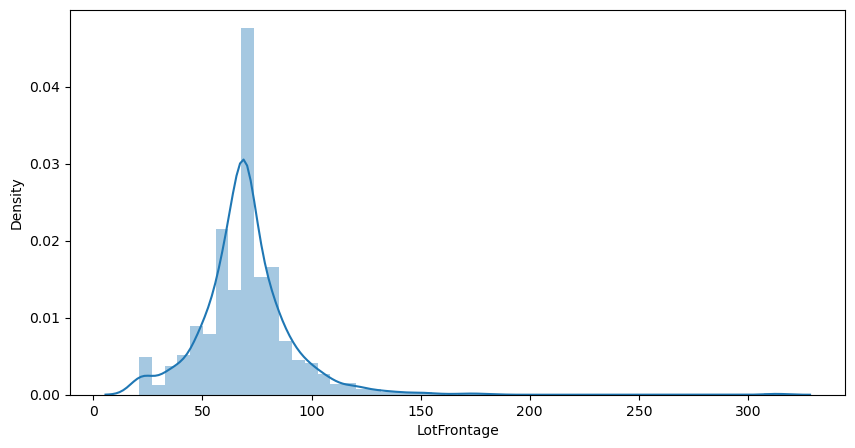

12.207687851233496


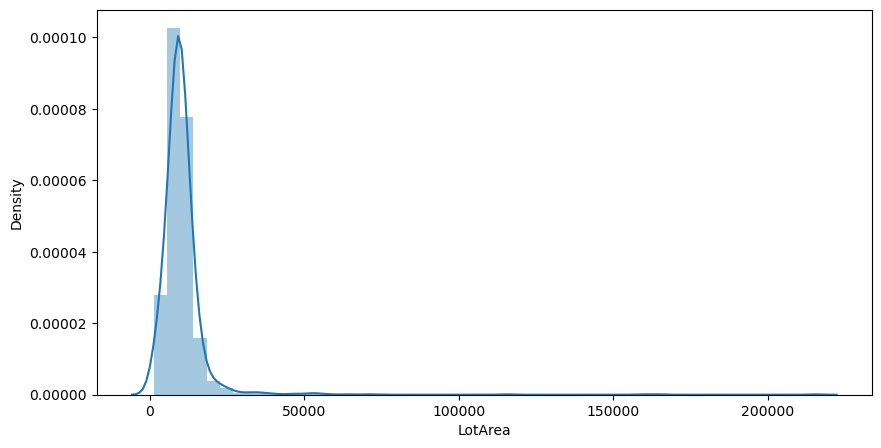

0.2169439277628693


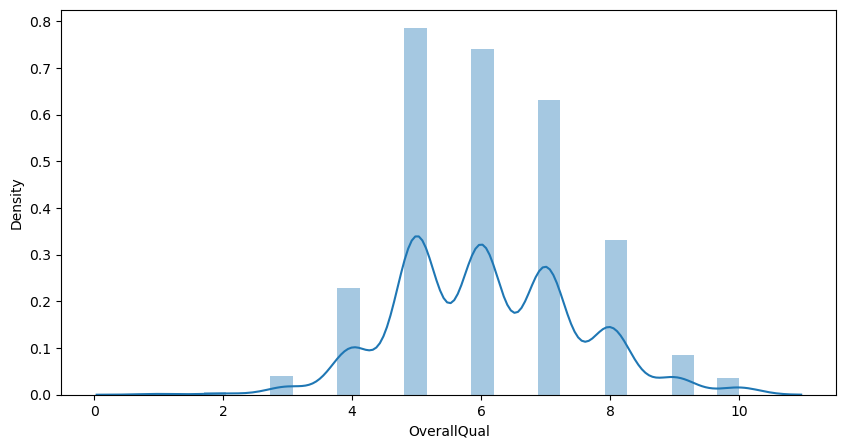

0.6930674724842182


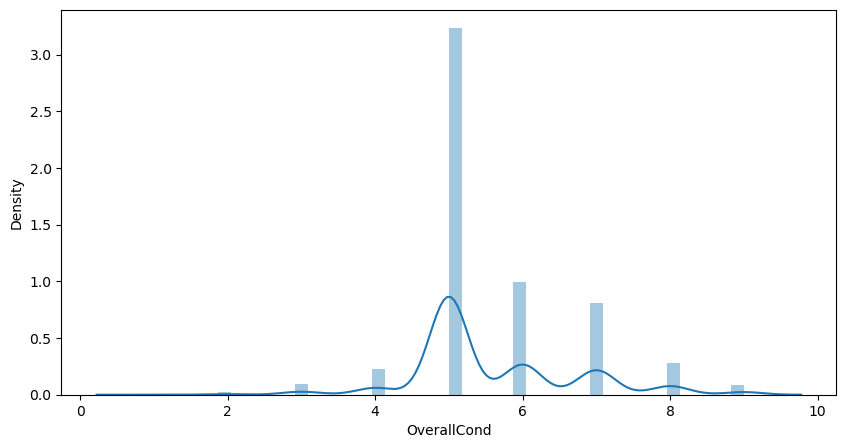

-0.613461172488183


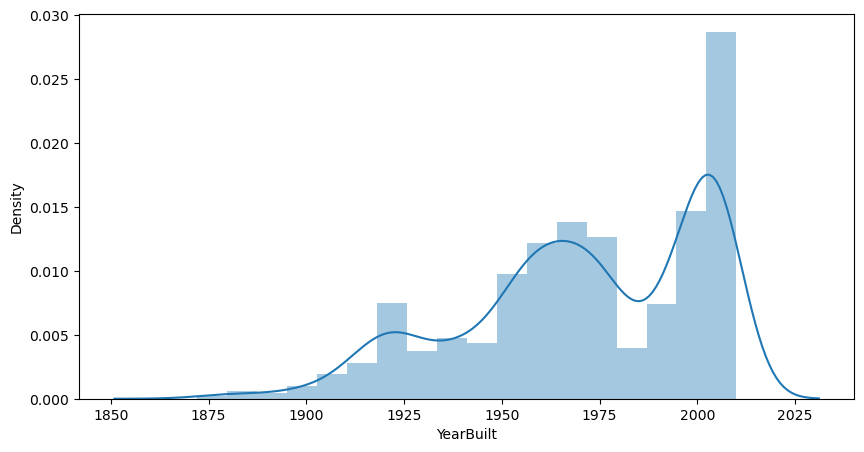

-0.5035620027004709


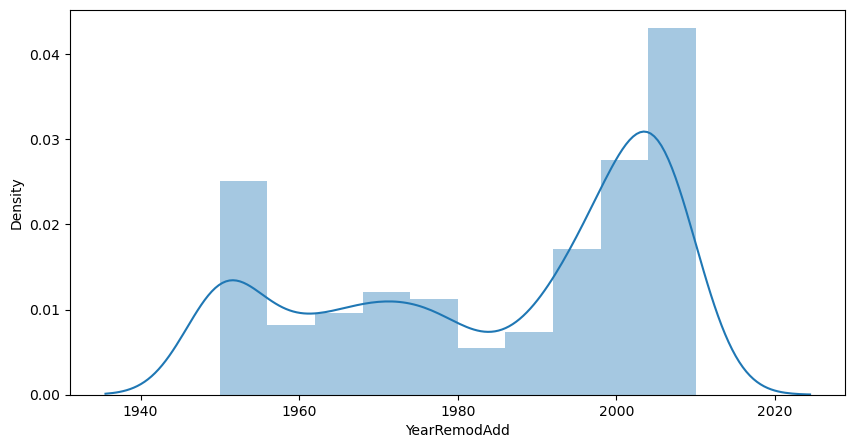

2.6776164510820997


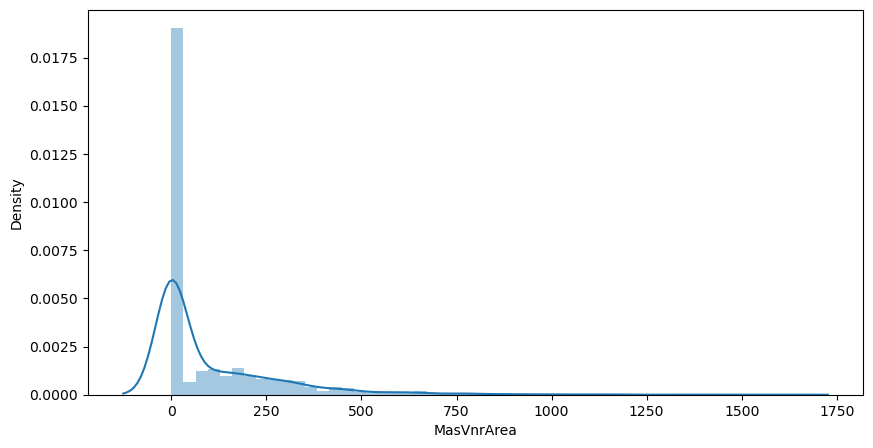

1.685503071910789


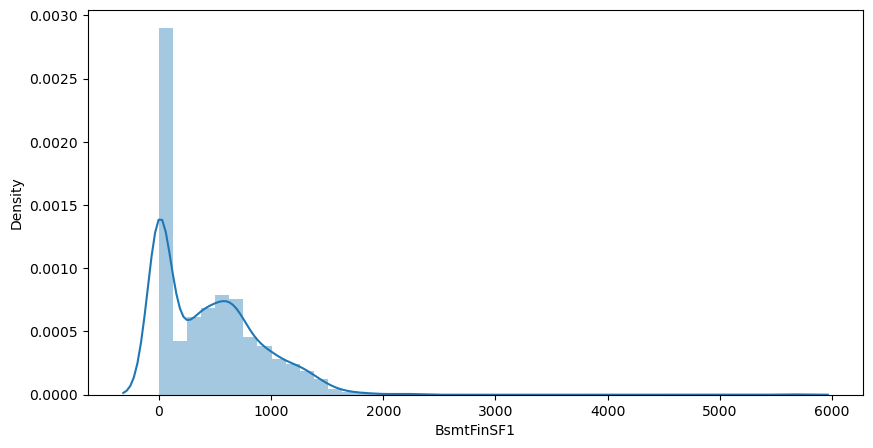

4.255261108933303


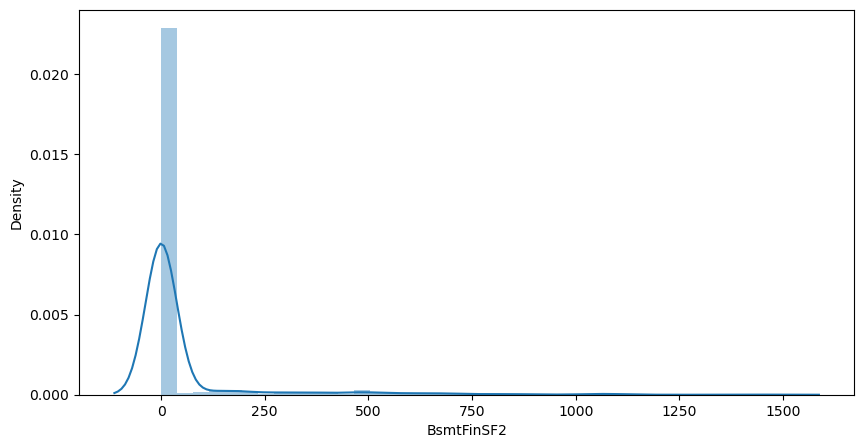

0.9202684528039037


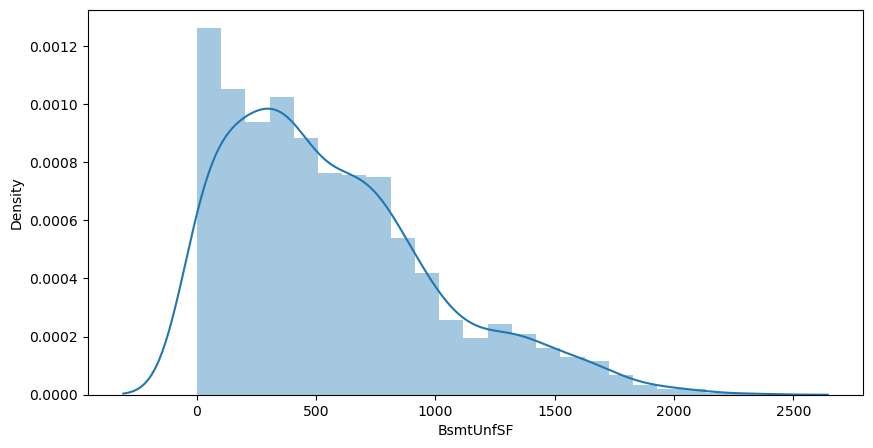

1.5242545490627664


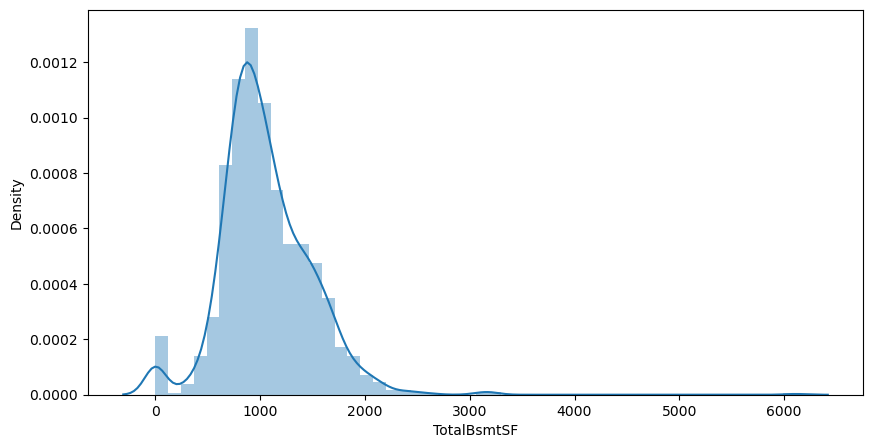

1.3767566220336365


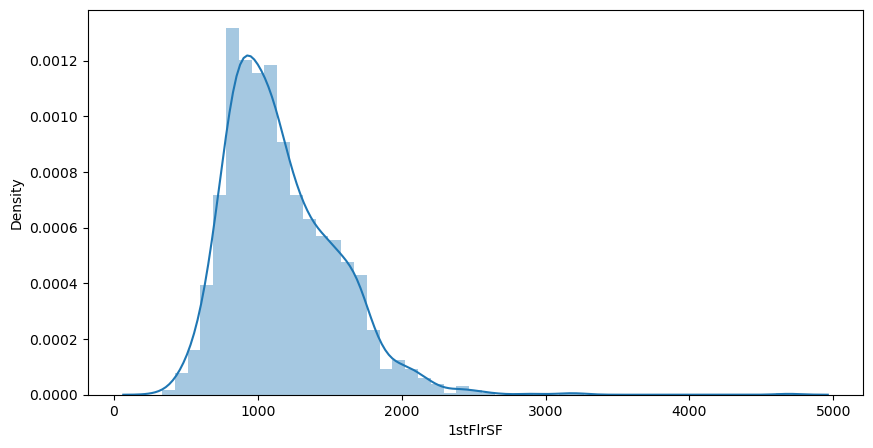

0.8130298163023265


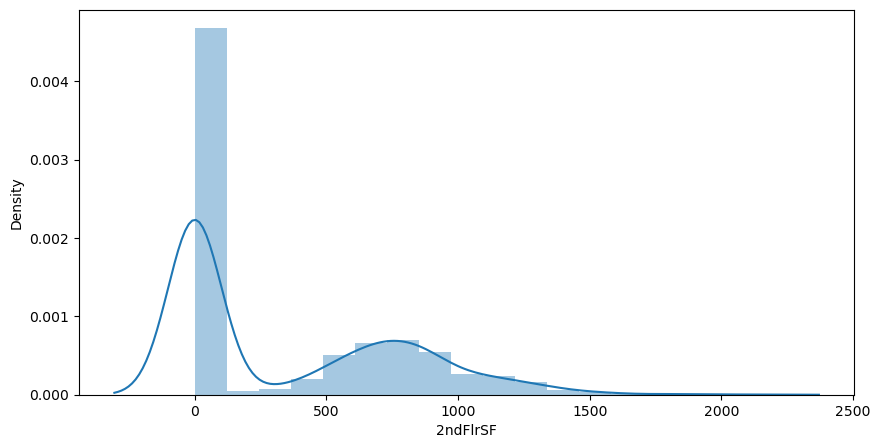

9.011341288465387


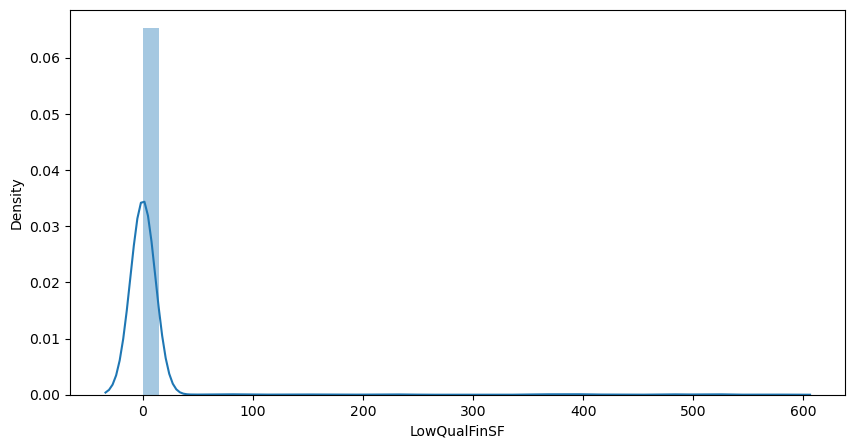

1.3665603560164552


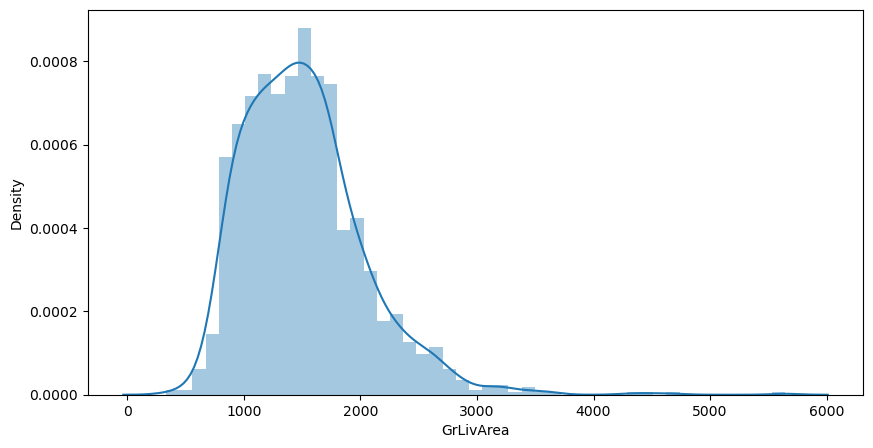

0.596066609663168


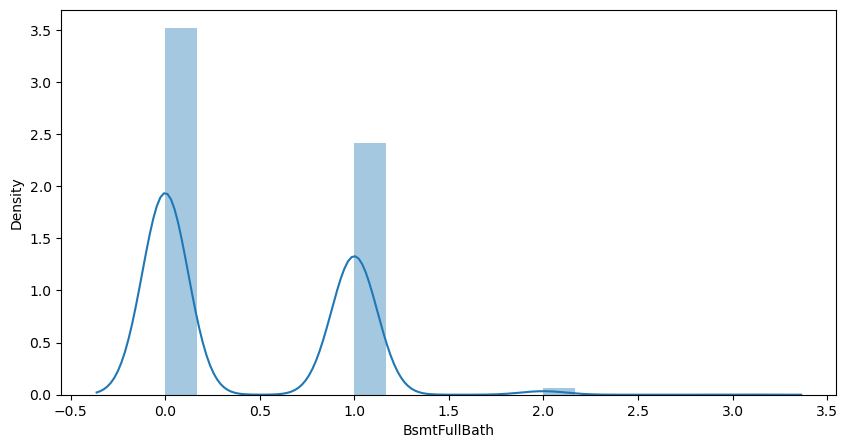

4.103402697955168


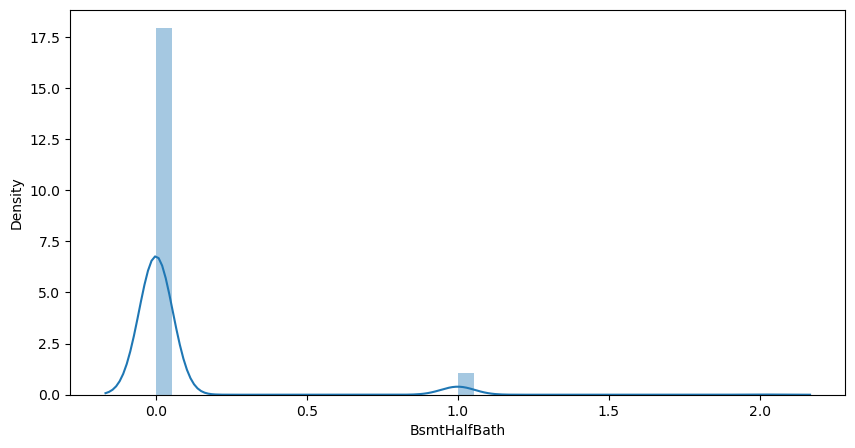

0.036561558402727165


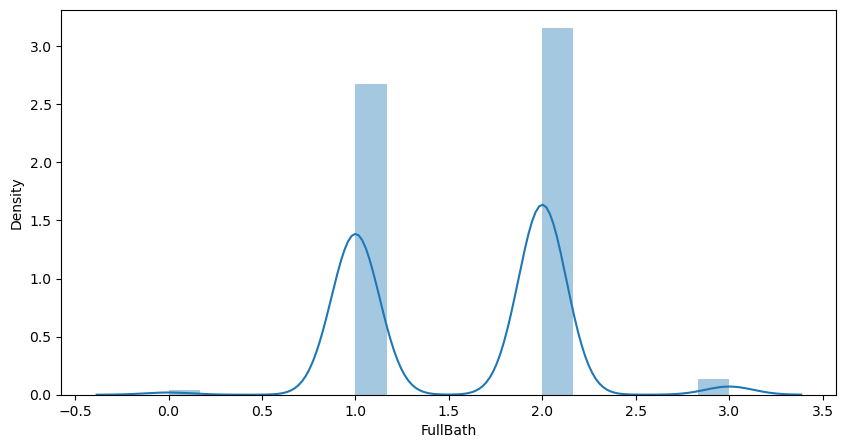

0.675897448233722


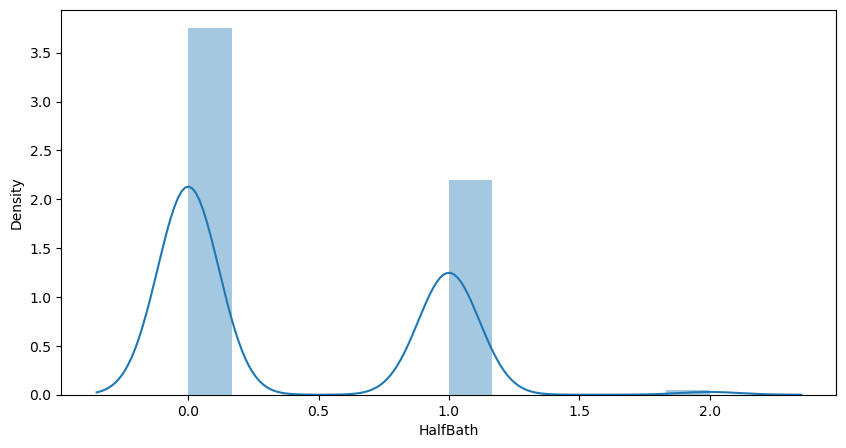

0.21179009627507137


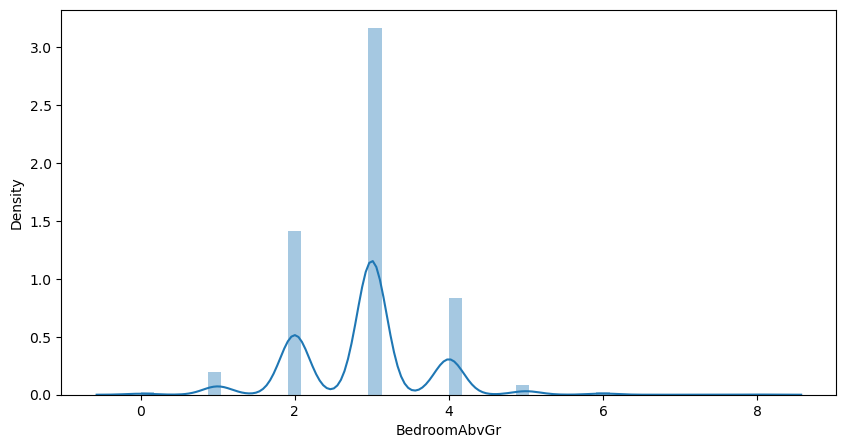

4.488396777072859


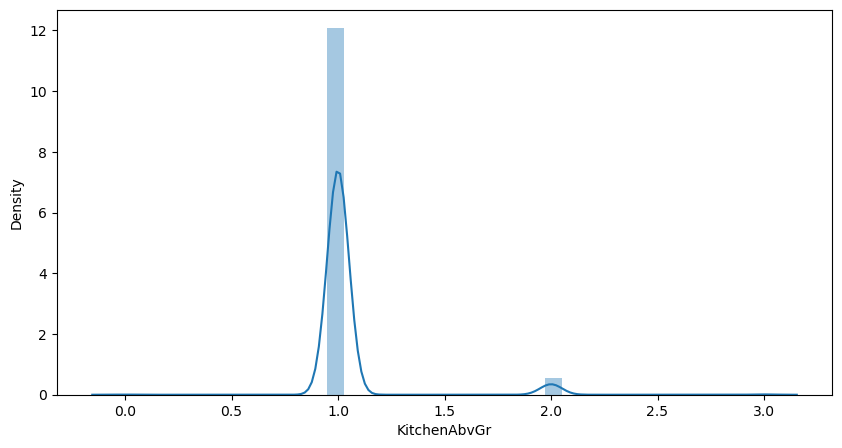

0.6763408364355531


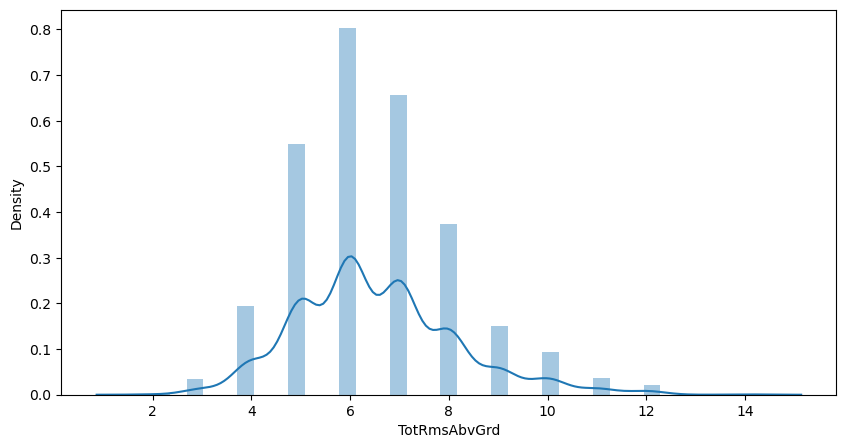

0.6495651830548841


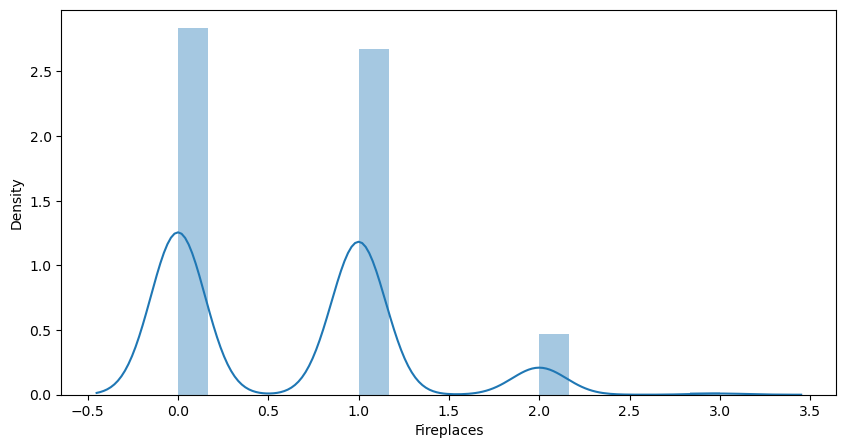

-0.3425489297486655


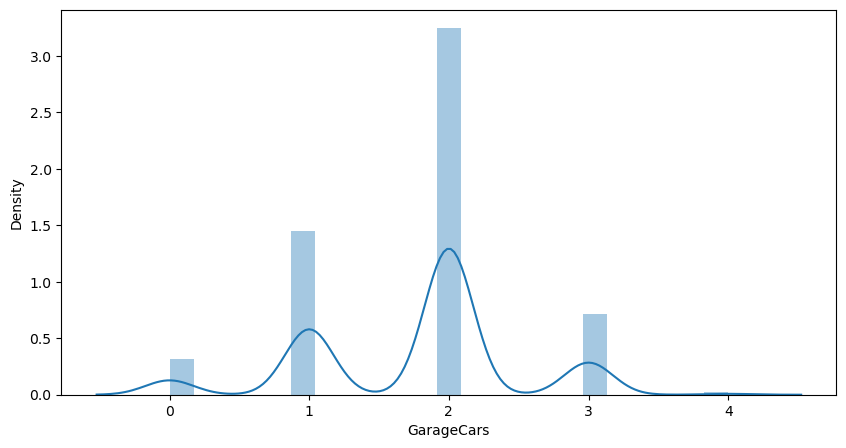

0.17998090674623907


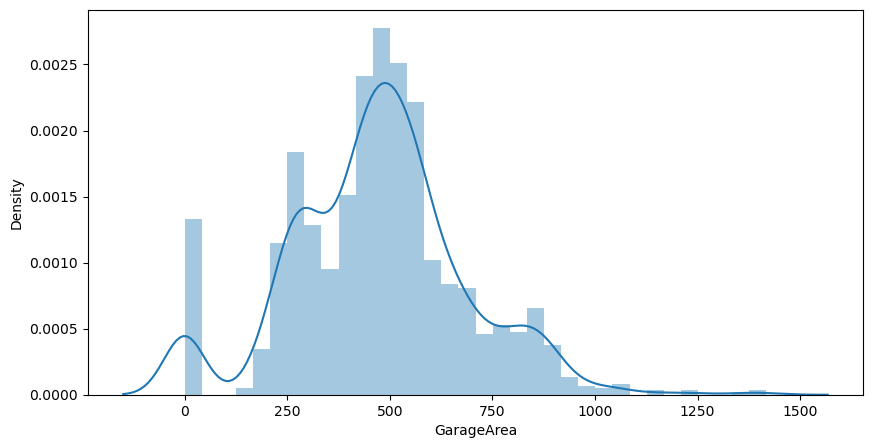

1.5413757571931312


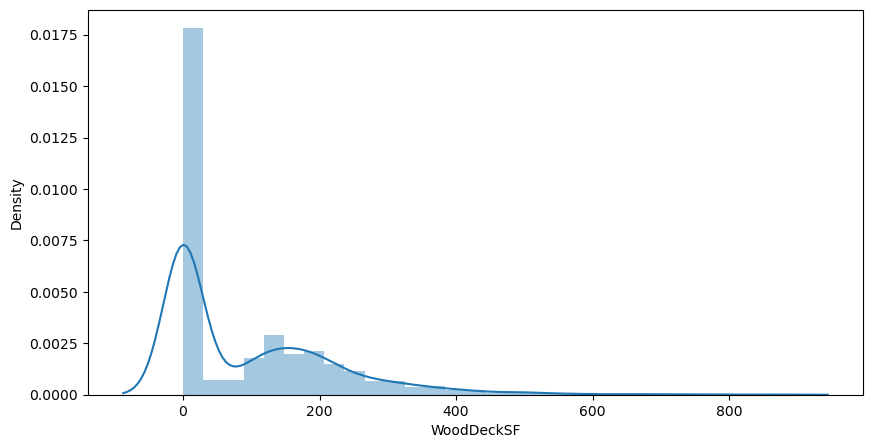

2.3643417403694404


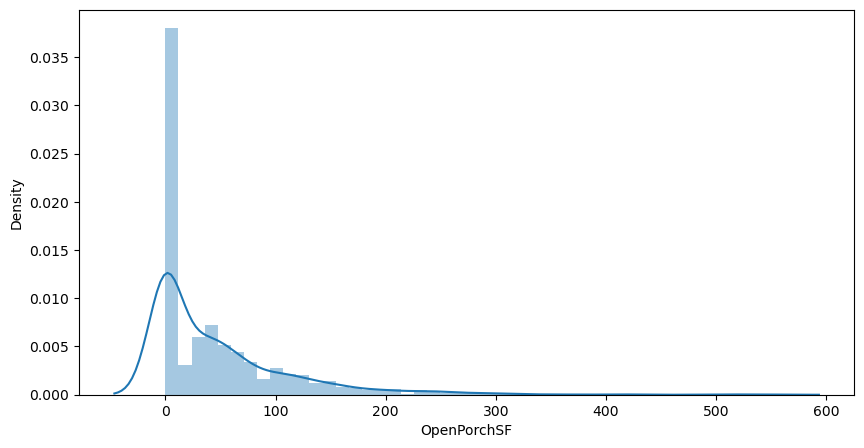

3.08987190371177


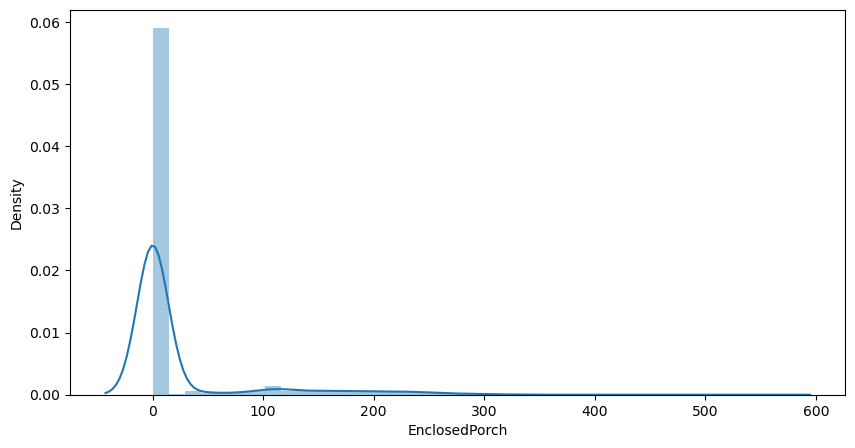

10.304342032693112


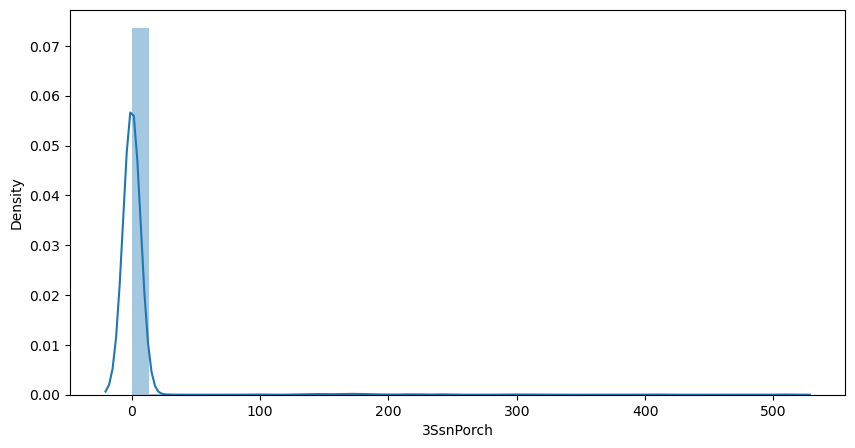

4.122213743143115


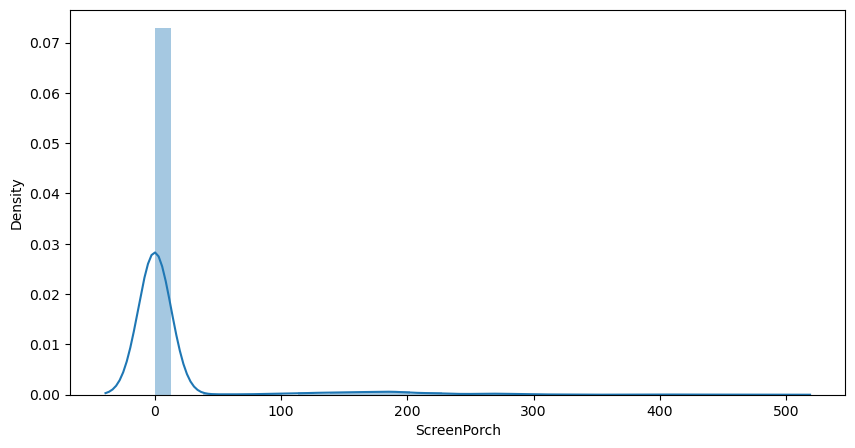

14.828373640750588


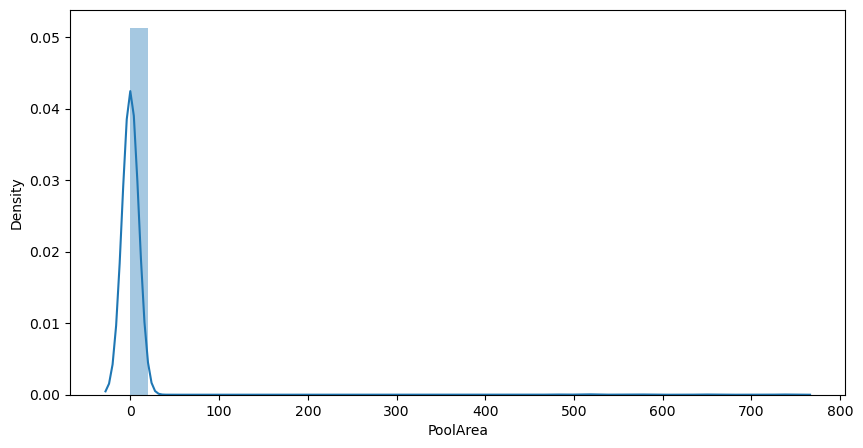

24.476794188821916


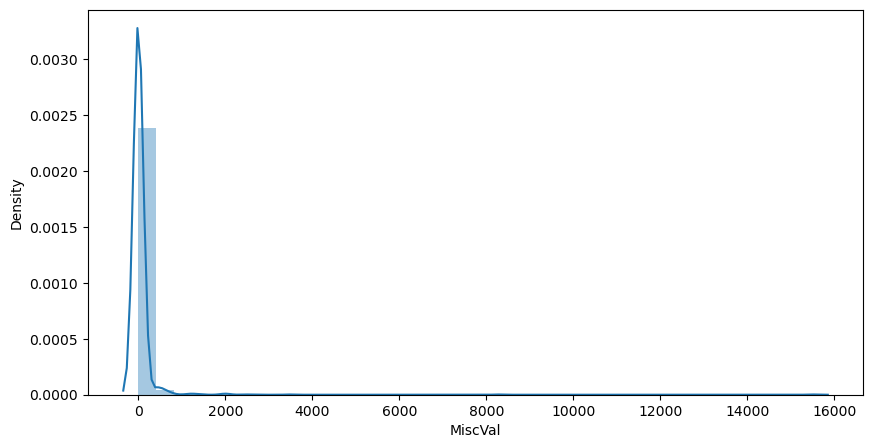

0.21205298505146022


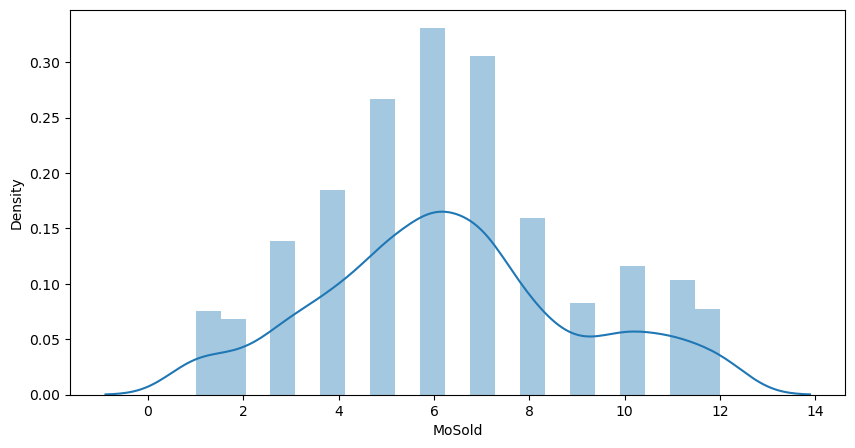

0.09626851386568028


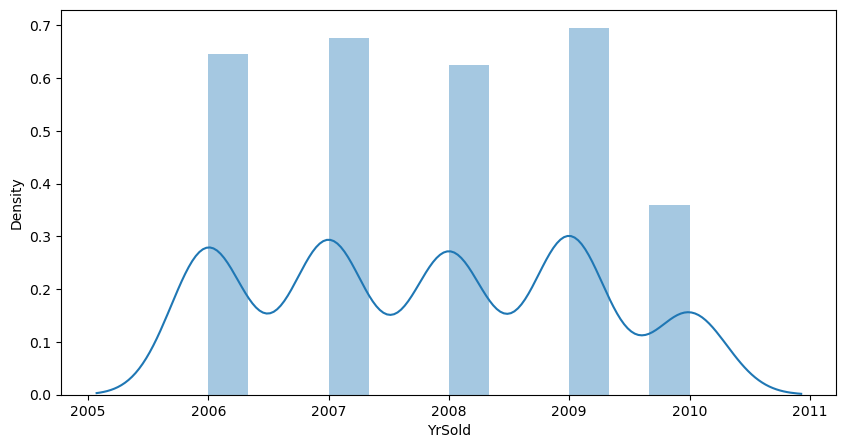

0.12133506220520406


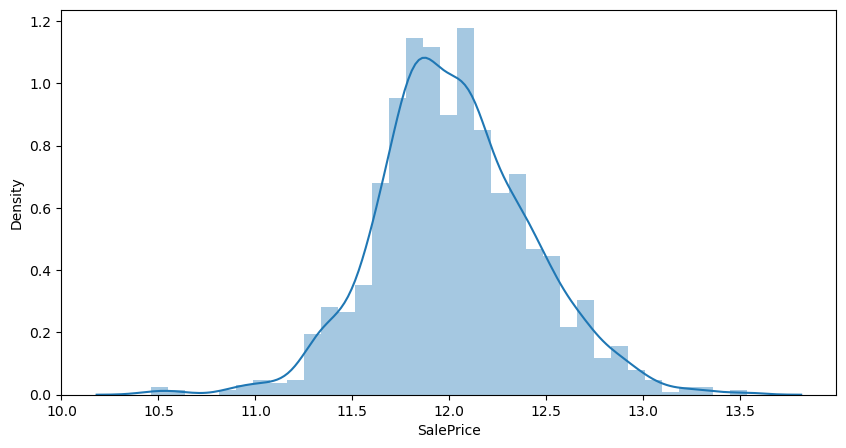

In [37]:
for i in df_num.columns:
    plt.figure(figsize = (10,5))
    sns.distplot( df[i])
    print(df_num[i].skew())
    plt.show()

In [39]:
df['KitchenAbvGr'].value_counts()

KitchenAbvGr
1    1392
2      65
3       2
0       1
Name: count, dtype: int64